# Transfer learning example on tabular data

2 similar regression tasks A and B

In [3]:
from re import X
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(0)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

mps


In [11]:


# -------------------------
# 1. Generate synthetic data
# -------------------------
def generate_data(N=1000, task="A",n=4,sdw=0.15):
    X = torch.randn(N, n)

    if task == "A":
        y = X[:, 0]*X[:,1] + np.sin(X[:, 1])+X[:, 2] +sdw*np.random.randn(N).astype(np.float32)
    else:  # Task B
        y = X[:, 0]*X[:,1] + X[:, 1] + X[:,1] * X[:, 2]+sdw*np.random.randn(N).astype(np.float32)

    return X, y.unsqueeze(1)

n=4
NA=3000
NB=200
X_A, y_A = generate_data(NA, "A",n)
X_A=X_A.to(device)
y_A=y_A.to(device)
X_B_train, y_B_train = generate_data(NB, "B",n)   # small dataset
X_B_val, y_B_val = generate_data(10*NB, "B",n)
X_B_train=X_B_train.to(device)
y_B_train=y_B_train.to(device)
X_B_val=X_B_val.to(device)
y_B_val=y_B_val.to(device)


print(X_A.shape, y_A.shape)
print(X_B_train.shape, y_B_train.shape)
print(X_B_val.shape, y_B_val.shape)

torch.Size([3000, 4]) torch.Size([3000, 1])
torch.Size([200, 4]) torch.Size([200, 1])
torch.Size([2000, 4]) torch.Size([2000, 1])


In [13]:

# -------------------------
# 2. Model
# -------------------------
class Net(nn.Module):
    def __init__(self,n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# 3. Training function
# -------------------------
def train(model, X, y, epochs=50, lr=0.01, verbose=False):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    losses = []

    for e in range(epochs):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if verbose and e%10 == 0:
          print(f"Epoch: {e} Loss: {loss.item():.4f}")
    return losses

def evaluate(model, X, y):
    with torch.no_grad():
        return nn.MSELoss()(model(X), y).item()


## Task B from scratch vs Transfer of Task A to Task B

In [22]:

# -------------------------
# 4. Step 1: Train on Task A
# -------------------------
model_A = Net(n).to(device)
print("Training on Task A")
train(model_A, X_A, y_A, verbose=True)

# Save pretrained weights
pretrained_weights = model_A.state_dict()

# -------------------------
# 5. Step 2: Train on Task B (from scratch)
# -------------------------
model_scratch = Net(n).to(device)
print("Training on Task B (from scratch)")
train(model_scratch, X_B_train, y_B_train, verbose=True)

loss_scratch = evaluate(model_scratch, X_B_val, y_B_val)

# -------------------------
# 6. Step 3: Transfer learning
# -------------------------
model_transfer = Net(n).to(device)
print("Training on Task B (transfer)")
model_transfer.load_state_dict(pretrained_weights)

# Fine-tune on Task B
train(model_transfer, X_B_train, y_B_train, verbose=True)

loss_transfer = evaluate(model_transfer, X_B_val, y_B_val)

# -------------------------
# 7. Show results
# -------------------------
print("\nFinal Validation Loss:")
print(f"From Scratch:      {loss_scratch:.4f}")
print(f"Transfer Learning: {loss_transfer:.4f}")



Training on Task A
Epoch: 0 Loss: 2.4681
Epoch: 10 Loss: 0.7692
Epoch: 20 Loss: 0.2405
Epoch: 30 Loss: 0.1668
Epoch: 40 Loss: 0.1160
Training on Task B (from scratch)
Epoch: 0 Loss: 3.2387
Epoch: 10 Loss: 1.5453
Epoch: 20 Loss: 0.3928
Epoch: 30 Loss: 0.2080
Epoch: 40 Loss: 0.1579
Training on Task B (transfer)
Epoch: 0 Loss: 2.4342
Epoch: 10 Loss: 0.8358
Epoch: 20 Loss: 0.3250
Epoch: 30 Loss: 0.1858
Epoch: 40 Loss: 0.1152

Final Validation Loss:
From Scratch:      0.2001
Transfer Learning: 0.1482


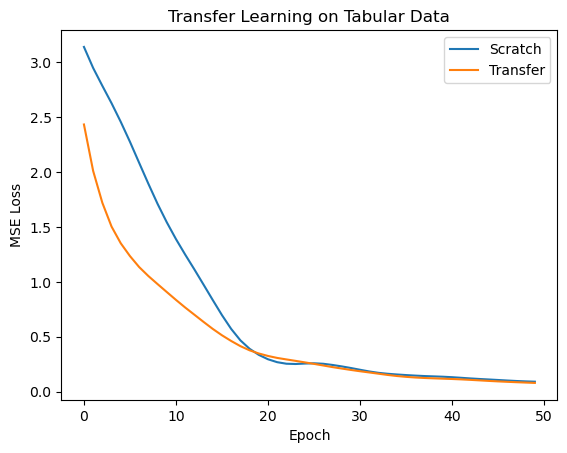

In [26]:
# -------------------------
# 8. Plot convergence
# -------------------------
model_transfer2 = Net(n).to(device)
loss_scratch_curve = train(model_transfer2, X_B_train, y_B_train)

model_transfer2.load_state_dict(pretrained_weights)
loss_transfer_curve = train(model_transfer2, X_B_train, y_B_train)

plt.plot(loss_scratch_curve, label="Scratch")
plt.plot(loss_transfer_curve, label="Transfer")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transfer Learning on Tabular Data")
plt.legend()
plt.show()